In [1]:
import numpy as np
float_formatter = lambda x: "%.3f" % x
np.set_printoptions(formatter={'float_kind':float_formatter})
from sklearn.datasets import make_circles
from sklearn.cluster import SpectralClustering, KMeans
from sklearn.metrics import pairwise_distances
from matplotlib import pyplot as plt
import networkx as nx
import seaborn as sns

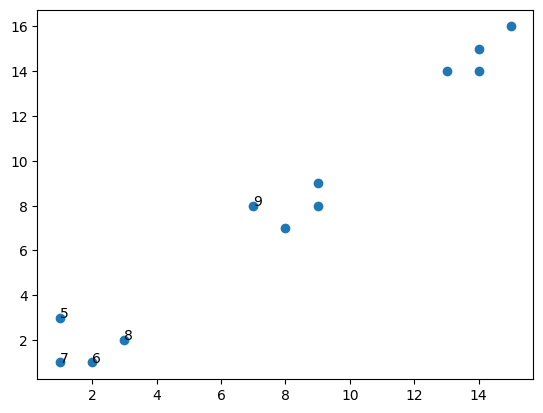

In [18]:
X = np.array([
    [1, 3], [2, 1], [1, 1],
    [3, 2], [7, 8], [9, 8],
    [9, 9], [8, 7], [13, 14],
    [14, 14], [15, 16], [14, 15]
])
fig, ax = plt.subplots()
ax.scatter(X[:,0],X[:,1] )
i=5
# enumerate(range(X.shape[0]))
for i, txt in enumerate(range(5,10)):
    ax.annotate(txt, X[i])


In [19]:
from scipy.spatial.distance import pdist, squareform
from sklearn.datasets import load_digits

digits = load_digits().data[:5] # Tomamos solo los primeros 5 para que sea legible
dist_matrix = squareform(pdist(digits, metric='euclidean'))
print(dist_matrix)

[[0.000 59.557 54.129 47.571 50.339]
 [59.557 0.000 41.629 45.475 47.906]
 [54.129 41.629 0.000 53.954 52.096]
 [47.571 45.475 53.954 0.000 51.215]
 [50.339 47.906 52.096 51.215 0.000]]


Aquí tienes las definiciones técnicas y formales de cada matriz, estructuradas matemáticamente para que puedas usarlas como referencia técnica en tu Jupyter Notebook.

---

## 1. Matriz de Adyacencia ($A$)

Define la estructura de conectividad del grafo. Es una matriz cuadrada de tamaño $n \times n$.

* **Definición:** $A_{ij} = 1$ si existe una arista entre el nodo $i$ y el nodo $j$; de lo contrario, $A_{ij} = 0$.
* **Ejemplo:** Para un grafo de 3 nodos donde el nodo 0 se conecta con el 1 y el 2:

$$A = \begin{pmatrix} 0 & 1 & 1 \\ 1 & 0 & 0 \\ 1 & 0 & 0 \end{pmatrix}$$



---

## 2. Matriz de Distancias ($D_{dist}$)

Representa la separación cuantitativa entre pares de puntos en un espacio métrico.

* **Definición:** Cada celda $(i, j)$ contiene el valor de una métrica de distancia (comúnmente la distancia Euclidiana) entre los vectores de características $x_i$ y $x_j$.
* **Ejemplo:** Distancias entre tres puntos en una línea:

$$D_{dist} = \begin{pmatrix} 0.0 & 2.5 & 5.0 \\ 2.5 & 0.0 & 2.5 \\ 5.0 & 2.5 & 0.0 \end{pmatrix}$$



---

## 3. Matriz de Grado ($D$)

Matriz diagonal que resume la conectividad local de cada nodo.

* **Definición:** Es una matriz donde los elementos fuera de la diagonal son 0. El elemento diagonal $D_{ii}$ es el grado del nodo $i$, calculado como la suma de la fila $i$ de la matriz de adyacencia: $D_{ii} = \sum_{j} A_{ij}$.
* **Ejemplo:** (Basado en la matriz de adyacencia del punto 1):

$$D = \begin{pmatrix} 2 & 0 & 0 \\ 0 & 1 & 0 \\ 0 & 0 & 1 \end{pmatrix}$$



---

## 4. Matriz de Afinidad ($W$)

Mide la similitud entre pares de puntos, generalmente normalizada entre 0 y 1.

* **Definición:** Se obtiene aplicando un kernel a la matriz de distancias. El más común es el Kernel RBF (Gaussiano): $W_{ij} = \exp(-\frac{\|x_i - x_j\|^2}{2\sigma^2})$.
* **Ejemplo:** Donde 1 indica identidad y valores cercanos a 0 indican alta disimilitud:

$$W = \begin{pmatrix} 1.0 & 0.8 & 0.2 \\ 0.8 & 1.0 & 0.5 \\ 0.2 & 0.5 & 1.0 \end{pmatrix}$$



---

## 5. Matriz Laplaciana ($L$)

Operador matricial que describe las propiedades fundamentales del grafo. Es clave para la reducción de dimensionalidad y el agrupamiento.

* **Definición:** En su forma no normalizada, se define como la diferencia entre la matriz de grado y la matriz de adyacencia (o afinidad): $L = D - A$.
* **Ejemplo:** (Usando $D$ y $A$ anteriores):

$$L = \begin{pmatrix} 2 & -1 & -1 \\ -1 & 1 & 0 \\ -1 & 0 & 1 \end{pmatrix}$$


* **Propiedad:** La cantidad de autovalores iguales a 0 en esta matriz indica el número de componentes conexas (grupos aislados) en el grafo.

In [20]:
from sklearn.cluster import DBSCAN
import numpy as np
X = np.array([[1, 2], [2, 2], [2, 3],
              [8, 7], [8, 8], [25, 80]])
clustering = DBSCAN(eps=3, min_samples=2).fit(X)
clustering.labels_
clustering

,"eps eps: float, default=0.5The maximum distance between two samples for one to be consideredas in the neighborhood of the other. This is not a maximum boundon the distances of points within a cluster. This is the mostimportant DBSCAN parameter to choose appropriately for your data setand distance function. Smaller values generally lead to more clusters.",3
,"min_samples min_samples: int, default=5The number of samples (or total weight) in a neighborhood for a point tobe considered as a core point. This includes the point itself. If`min_samples` is set to a higher value, DBSCAN will find denser clusters,whereas if it is set to a lower value, the found clusters will be moresparse.",2
,"metric metric: str, or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array. If metric is a string or callable, it must be one ofthe options allowed by :func:`sklearn.metrics.pairwise_distances` forits metric parameter.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors for DBSCAN... versionadded:: 0.17 metric *precomputed* to accept precomputed sparse matrix.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function... versionadded:: 0.19",None
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'The algorithm to be used by the NearestNeighbors moduleto compute pointwise distances and find nearest neighbors.'auto' will attempt to decide the most appropriate algorithmbased on the values passed to :meth:`fit` method.See :class:`~sklearn.neighbors.NearestNeighbors` documentation fordetails.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or cKDTree. This can affect the speedof the construction and query, as well as the memory requiredto store the tree. The optimal value dependson the nature of the problem.",30
,"p p: float, default=NoneThe power of the Minkowski metric to be used to calculate distancebetween points. If None, then ``p=2`` (equivalent to the Euclideandistance). When p=1, this is equivalent to Manhattan distance.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


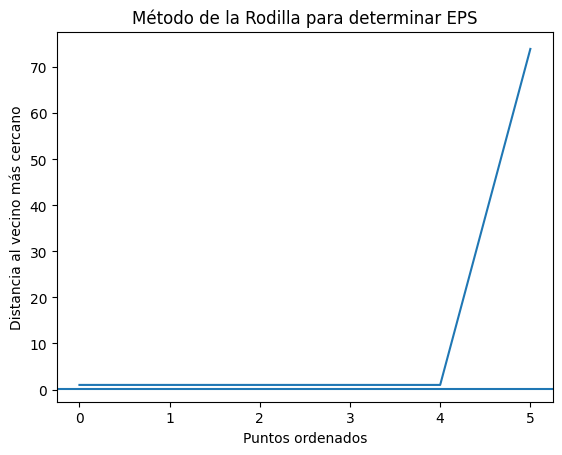

In [22]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

# 1. Definir k (usualmente min_samples)
k = 2 
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X)

# 2. Calcular distancias
distances, indices = neighbors_fit.kneighbors(X)

# 3. Ordenar distancias (tomamos la columna de la distancia al k-ésimo vecino)
distances = np.sort(distances[:, k-1], axis=0)

# 4. Graficar
plt.plot(distances)
plt.xlabel("Puntos ordenados")
plt.ylabel("Distancia al vecino más cercano")
plt.title("Método de la Rodilla para determinar EPS")
plt.axhline(0.15)
plt.show()